# Package Library

In [1]:
import pandas as pd
import numpy as np
from itertools import combinations
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import kstest
from scipy.stats import probplot
import math
import seaborn as sns

# Import Data

In [2]:
# Load csv dataset
df = pd.read_csv('Groceries_dataset.csv')
df

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
...,...,...,...
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice


# Overview Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [4]:
# Ubah format tipe data
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Member_number    38765 non-null  int64         
 1   Date             38765 non-null  datetime64[ns]
 2   itemDescription  38765 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 908.7+ KB


In [6]:
df['itemDescription'].describe()

count          38765
unique           167
top       whole milk
freq            2502
Name: itemDescription, dtype: object

In [7]:
# Jumlah quantity produk
df['itemDescription'].value_counts()

itemDescription
whole milk               2502
other vegetables         1898
rolls/buns               1716
soda                     1514
yogurt                   1334
                         ... 
rubbing alcohol             5
bags                        4
baby cosmetics              3
kitchen utensil             1
preservation products       1
Name: count, Length: 167, dtype: int64

**Analisis dan Penjelasan Dataset**

**Sumber Data:** [Groceries Dataset (Kaggle)](https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset/data)

Dataset ini merupakan catatan transaksi ritel yang terdiri dari **3 kolom utama**:

1. **Member_number**: ID unik milik pelanggan.
2. **Date**: Tanggal saat transaksi dilakukan.
3. **itemDescription**: Deskripsi atau nama produk yang dibeli.

---

**Wawasan Data (Data Insights)**

Berdasarkan eksplorasi awal, berikut adalah ringkasan statistik dari dataset ini:

* **Total Baris**: Dataset memiliki **38.765 baris** data.
* **Jumlah Pelanggan**: Terdapat **3.898 anggota unik**, yang merepresentasikan total 3.898 riwayat transaksi.
* **Variasi Produk**: Terdapat **167 jenis item** berbeda yang tersedia di dalam dataset.
* **Produk Terlaris**: Item yang paling sering dibeli adalah **'whole milk'** dengan frekuensi sebanyak **2.502** kali.

**Statistik Frekuensi:**
* **Rata-rata** pembelian item: **232**.
* **Median** (nilai tengah) pembelian item: **85**.

---

**Langkah Pra-pemrosesan (Data Preprocessing)**

* **Groupby**: Data akan dikelompokkan berdasarkan **Member_number** untuk melihat keranjang belanja pelanggan.
* **Drop Column**: Kolom **Date** akan dihapus karena tidak digunakan dalam analisis ini.
* **Data Cleaning**: Dataset tidak memiliki nilai kosong (**no missing values**).

# Data Cleaning

In [8]:
# Melihat jumlah duplikat
df.duplicated().sum()

np.int64(759)

In [9]:
# Hapus duplikat data
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
# memeriksa data kosong
pd.isnull(df).sum()

Member_number      0
Date               0
itemDescription    0
dtype: int64

In [12]:
# cek kesesuaian input data numerik
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols

outlier_summary = {}

# mencari outlier menggunakan metode IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
# Filter data outlier
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = {
        'lower_bound': lower,
        'upper_bound': upper,
        'n_outliers': outliers.shape[0],
        'percentage': (outliers.shape[0])/len(df[col])
    }
pd.DataFrame(outlier_summary)

,Member_number
lower_bound,-1008.0
upper_bound,7016.0
n_outliers,0.0
percentage,0.0


# EDA

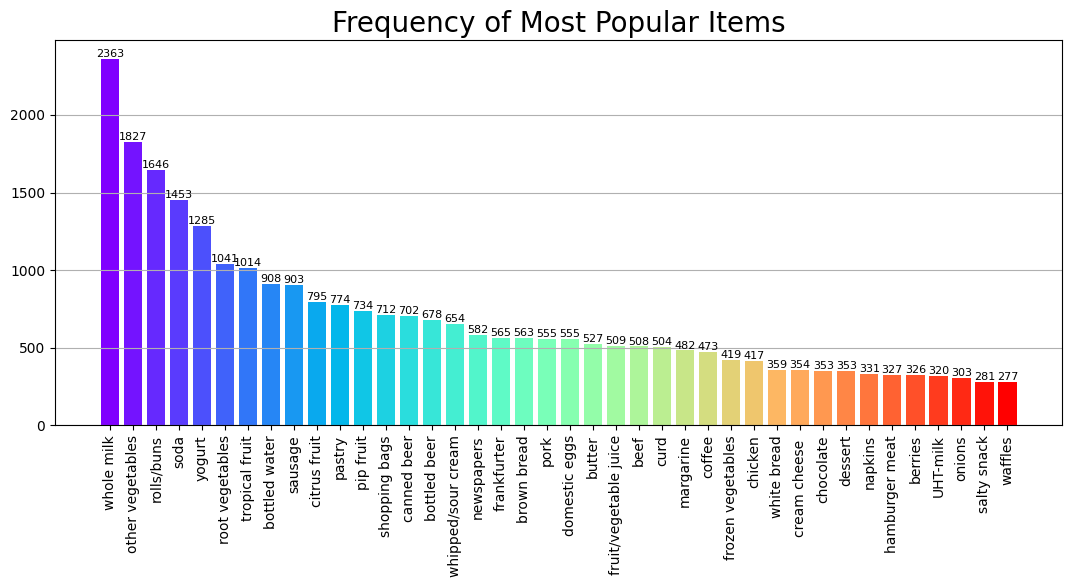

In [13]:
# Ambil 40 item teratas
top_items = df['itemDescription'].value_counts().head(40)

# Warna
color = plt.cm.rainbow(np.linspace(0, 1, 40))

# Plot
plt.figure(figsize=(13,5))
bars = plt.bar(top_items.index, top_items.values, color=color)

plt.title('Frequency of Most Popular Items', fontsize=20)
plt.xticks(rotation=90)
plt.grid(axis='y')

# 🔹 Tambahkan anotasi
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.show()

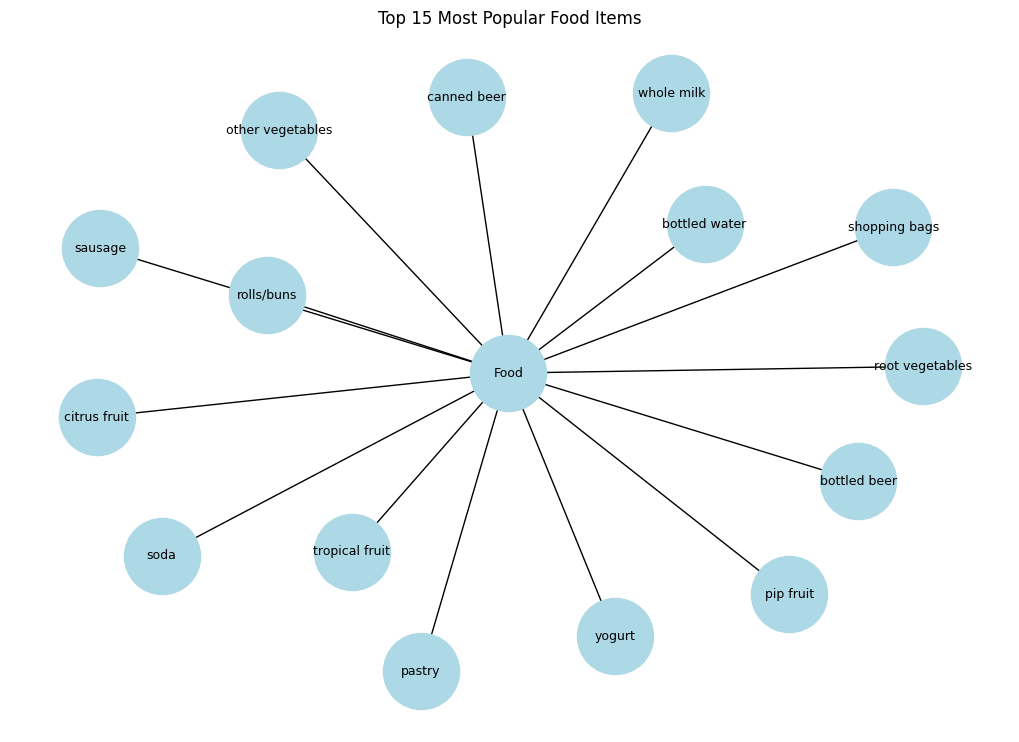

In [14]:
# Ambil 15 item teratas
top_items = df['itemDescription'].value_counts().head(15).reset_index()
top_items.columns = ['item', 'count']

# Tambahkan node pusat
top_items['category'] = 'Food'

# Buat graph
G = nx.from_pandas_edgelist(
    top_items,
    source='category',
    target='item'
)

# Plot
plt.figure(figsize=(10,7))
pos = nx.spring_layout(G, k=0.5)

nx.draw(
    G, pos,
    with_labels=True,
    node_color='lightblue',
    node_size=3000,
    font_size=9
)

plt.title("Top 15 Most Popular Food Items")
plt.show()

**Analisis Visualisasi Data**

Berdasarkan grafik yang dihasilkan, berikut adalah poin-poin pengamatan utama:

**1. Top 15 Most Popular Food Items (Network Graph)**
Grafik jaringan ini menunjukkan 15 produk makanan yang paling sering dibeli oleh pelanggan:
* **Item Utama**: Produk seperti **whole milk**, **other vegetables**, **rolls/buns**, dan **soda** muncul sebagai item dengan tingkat popularitas tertinggi.
* **Variasi Produk**: Pelanggan juga sering membeli kategori buah-buahan (tropical fruit, citrus fruit, pip fruit) serta produk pelengkap seperti shopping bags.

In [15]:
df_date=df.set_index(['Date']) ## Setting date as index for plotting purpose
df_date

,Member_number,itemDescription
Date,,
2015-07-21,1808,tropical fruit
2015-01-05,2552,whole milk
2015-09-19,2300,pip fruit
2015-12-12,1187,other vegetables
2015-02-01,3037,whole milk
...,...,...
2014-10-08,4471,sliced cheese
2014-02-23,2022,candy
2014-04-16,1097,cake bar


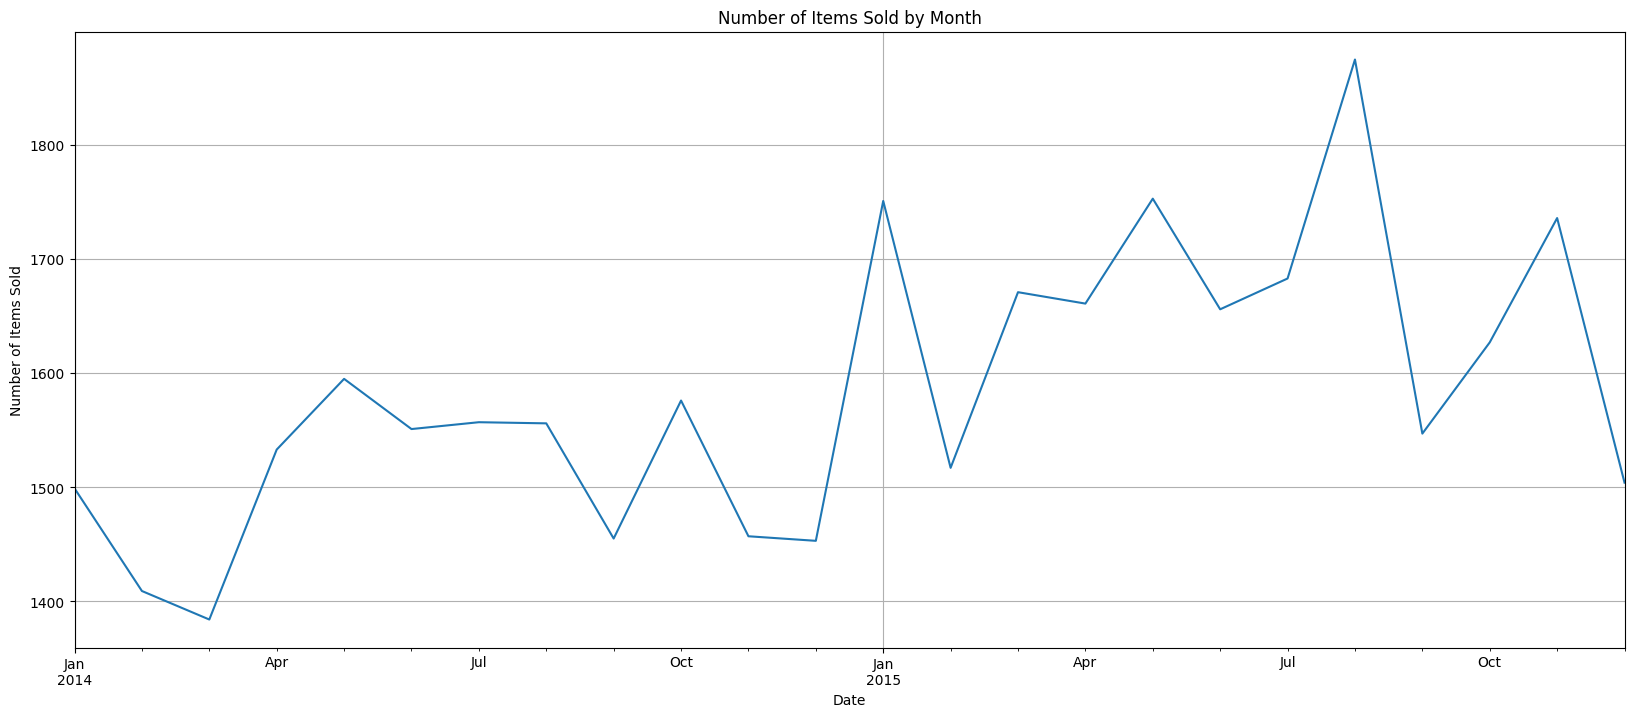

In [16]:
# Resample monthly and count items
monthly_items = df_date.resample('ME')['itemDescription'].count()

# Plot
ax = monthly_items.plot(
    figsize=(20, 8),
    grid=True,
    title="Number of Items Sold by Month"
)

ax.set_xlabel("Date")
ax.set_ylabel("Number of Items Sold")

plt.show()

**2. Number of Items Sold by Month (Line Chart)**
Grafik garis ini menunjukkan tren volume penjualan dari Januari 2014 hingga akhir 2015:
* **Tren Pertumbuhan**: Terlihat adanya tren kenaikan jumlah item yang terjual secara keseluruhan dari tahun 2014 ke tahun 2015.
* **Puncak Penjualan**: Penjualan mencapai titik tertinggi (peak) pada sekitar **Agustus 2015**, di mana jumlah item terjual melampaui angka sekitar 1.900.
* **Fluktuasi**: Terdapat fluktuasi bulanan yang cukup dinamis, dengan titik terendah terjadi pada awal tahun 2014.

# Apriori Implementation

In [22]:
# Buat TransactionID
df['TransactionID'] = (
    df['Member_number'].astype(str) + "_" + df['Date'].astype(str)
)
df['TransactionID']

/var/folders/1k/sdmmxldn72x7m1dp7r9vnbg80000gn/T/ipykernel_1924/4258333637.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TransactionID'] = (


0        1808_2015-07-21
1        2552_2015-01-05
2        2300_2015-09-19
3        1187_2015-12-12
4        3037_2015-02-01
              ...       
38760    4471_2014-10-08
38761    2022_2014-02-23
38762    1097_2014-04-16
38763    1510_2014-12-03
38764    1521_2014-12-26
Name: TransactionID, Length: 38006, dtype: object

In [23]:
transactions = (
    df.groupby('TransactionID')['itemDescription']
    .apply(list)
    .tolist()
)

## Buat basket size

In [24]:
# Hitung jumlah item per transaksi
basket_size_df = df.groupby('TransactionID')['itemDescription'].count().reset_index()

basket_size_df.columns = ['TransactionID', 'basket_size']

basket_size_df

,TransactionID,basket_size
0,1000_2014-06-24,3
1,1000_2015-03-15,4
2,1000_2015-05-27,2
3,1000_2015-07-24,2
4,1000_2015-11-25,2
...,...,...
14958,4999_2015-05-16,2
14959,4999_2015-12-26,2
14960,5000_2014-03-09,2
14961,5000_2014-11-16,2


In [25]:
df = df.merge(basket_size_df, on='TransactionID', how='left')
df

,Member_number,Date,itemDescription,TransactionID,basket_size
0,1808,2015-07-21,tropical fruit,1808_2015-07-21,3
1,2552,2015-01-05,whole milk,2552_2015-01-05,3
2,2300,2015-09-19,pip fruit,2300_2015-09-19,3
3,1187,2015-12-12,other vegetables,1187_2015-12-12,3
4,3037,2015-02-01,whole milk,3037_2015-02-01,3
...,...,...,...,...,...
38001,4471,2014-10-08,sliced cheese,4471_2014-10-08,3
38002,2022,2014-02-23,candy,2022_2014-02-23,3
38003,1097,2014-04-16,cake bar,1097_2014-04-16,3
38004,1510,2014-12-03,fruit/vegetable juice,1510_2014-12-03,3


## Distribusi Data

In [26]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:

    # Standarisasi (Z-score)
    data_z = (df[col] - df[col].mean()) / df[col].std()

    # Drop NA jika ada
    data_z = data_z.dropna()

    # Uji KS
    stat, p = kstest(data_z, 'norm')

    print(f"Kolom: {col}")
    print(f"  Statistik uji : {stat:.4f}")
    print(f"  p-value       : {p:.6f}")

    if p > 0.05:
        print("  ➜ Data berdistribusi normal\n")
    else:
        print("  ➜ Data tidak berdistribusi normal\n")

Kolom: Member_number
  Statistik uji : 0.0595
  p-value       : 0.000000
  ➜ Data tidak berdistribusi normal

Kolom: basket_size
  Statistik uji : 0.2821
  p-value       : 0.000000
  ➜ Data tidak berdistribusi normal



In [27]:
# Pilih semua kolom dengan tipe data integer
int_cols = df.select_dtypes(include=['int64', 'int32', 'float64']).columns

# Hitung Q1, Q3, dan IQR
q1 = df[int_cols].quantile(0.25)
q3 = df[int_cols].quantile(0.75)
iqr = q3 - q1

# Hitung batas bawah dan batas atas
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# Buat mask untuk mendeteksi outlier
mask = (df[int_cols] < lower) | (df[int_cols] > upper)

# Ambil baris yang memiliki minimal satu outlier
outliers = df[mask.any(axis=1)]

# Tampilkan kolom integer yang mengandung outlier
outliers[int_cols]

,Member_number,basket_size
2103,3036,8
2104,2465,9
2106,1366,9
2107,3741,8
2108,2230,8
...,...,...
35591,3308,8
35592,1183,8
35593,1999,8
35595,3608,8


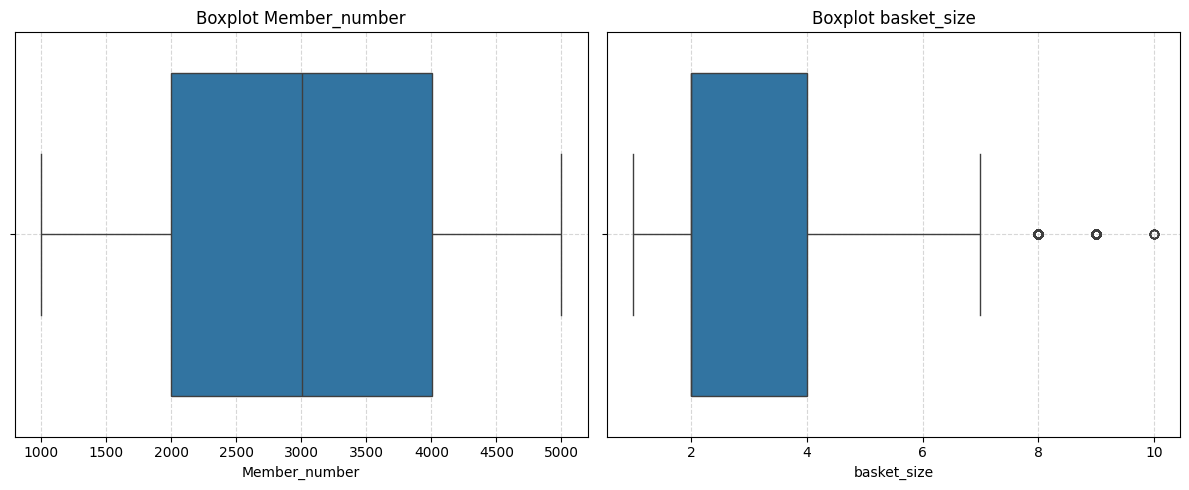

In [28]:
# Ambil semua kolom integer
int_cols = df.select_dtypes(include=['int64', 'int32', 'float64']).columns

# Tentukan jumlah kolom
n_cols = len(int_cols)

# Tentukan jumlah baris (2 plot per baris)
n_rows = math.ceil(n_cols / 2)

# Buat subplot
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 5*n_rows))

# Ubah axes jadi 1D array supaya mudah di-loop
axes = axes.flatten()

# Loop untuk membuat boxplot tiap kolom
for i, col in enumerate(int_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot {col}')
    axes[i].grid(True, linestyle='--', alpha=0.5)

# Hapus subplot kosong jika jumlah kolom ganjil
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## One-Hot Encoding

In [29]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print("Encoded Shape:", df_encoded.shape)

Encoded Shape: (14963, 167)


In [30]:
# Compute the support
support = df_encoded.mean()
support = pd.DataFrame(support, columns=['support']).sort_values('support', ascending=False)

# Print the support
support.head()

,support
whole milk,0.157923
other vegetables,0.122101
rolls/buns,0.110005
soda,0.097106
yogurt,0.085879


In [31]:
# Frequent Itemsets (Apriori)
frequent_itemsets = apriori(
    df_encoded,
    min_support=0.001,
    use_colnames=True
)

frequent_itemsets

,support,itemsets
0,0.004010,(Instant food products)
1,0.021386,(UHT-milk)
2,0.001470,(abrasive cleaner)
3,0.001938,(artif. sweetener)
4,0.008087,(baking powder)
...,...,...
745,0.001136,"(rolls/buns, whole milk, sausage)"
746,0.001002,"(rolls/buns, whole milk, soda)"
747,0.001337,"(rolls/buns, whole milk, yogurt)"
748,0.001069,"(whole milk, soda, sausage)"


In [32]:
# Mengurutkan produk yang sering dibeli
frequent_itemsets_sorted = frequent_itemsets.sort_values(
    by='support',
    ascending=False
)

frequent_itemsets_sorted.head(10)

,support,itemsets
146,0.157923,(whole milk)
90,0.122101,(other vegetables)
109,0.110005,(rolls/buns)
123,0.097106,(soda)
147,0.085879,(yogurt)
110,0.069572,(root vegetables)
139,0.067767,(tropical fruit)
10,0.060683,(bottled water)
115,0.060349,(sausage)
28,0.053131,(citrus fruit)


In [33]:
frequent_itemsets_sorted['itemsets'] = frequent_itemsets_sorted['itemsets'].apply(
    lambda x: ', '.join(sorted(list(x))) if isinstance(x, frozenset) else x
)

In [34]:
frequent_itemsets_sorted

,support,itemsets
146,0.157923,whole milk
90,0.122101,other vegetables
109,0.110005,rolls/buns
123,0.097106,soda
147,0.085879,yogurt
...,...,...
344,0.001002,"chicken, margarine"
201,0.001002,"bottled beer, chicken"
202,0.001002,"bottled beer, chocolate"
516,0.001002,"hamburger meat, pastry"


In [35]:
frequent_itemsets_sorted.to_excel("Support_MarketBasket.xlsx", index=False)

In [36]:
# total transaksi
total_transactions = df['TransactionID'].nunique()

# hitung jumlah produk
item_count = df.groupby('itemDescription')['TransactionID'].nunique().reset_index()
item_count.columns = ['item', 'transaction_total']

# hitung support
item_count['support'] = item_count['transaction_total'] / total_transactions

item_count.sort_values('support', ascending=False).head()

,item,transaction_total,support
164,whole milk,2363,0.157923
102,other vegetables,1827,0.122101
122,rolls/buns,1646,0.110005
138,soda,1453,0.097106
165,yogurt,1285,0.085879


In [37]:
item_count.to_excel("item_MarketBasket1.xlsx", index=False)

**Analisis Frequent Itemsets (Algoritma Apriori)**

Menggunakan algoritma Apriori dengan ambang batas *minimum support* sebesar **0.001**, berikut adalah temuan kuncinya:

* **Dominasi Produk Tunggal**: **Whole milk** memiliki tingkat *support* tertinggi yaitu **0.157** (muncul di ~15.7% transaksi), disusul oleh **other vegetables** (**0.122**).
* **Kombinasi Produk (Bundling)**: Ditemukan pola pembelian bersama yang menarik, seperti:
    * `{rolls/buns, sausage, whole milk}`
    * `{yogurt, rolls/buns, whole milk}`
* **Insight Bisnis**: Pelanggan yang membeli sosis atau yogurt cenderung menyertakan susu (whole milk) dan roti (rolls/buns) dalam satu keranjang belanja. Hal ini dapat digunakan untuk strategi penempatan barang yang berdekatan di toko.

## Sorting by Confidence and Lift

In [25]:
# Association Rules

rules = association_rules(
    frequent_itemsets_sorted,
    metric="confidence",
    min_threshold=0.1
)

rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(other vegetables),(whole milk),0.122101,0.157923,0.014837,0.121511,0.769430,1.0,-0.004446,0.958551,-0.254477,0.055948,-0.043241,0.107730
1,(rolls/buns),(whole milk),0.110005,0.157923,0.013968,0.126974,0.804028,1.0,-0.003404,0.964550,-0.214986,0.055000,-0.036752,0.107711
2,(soda),(whole milk),0.097106,0.157923,0.011629,0.119752,0.758296,1.0,-0.003707,0.956636,-0.260917,0.047776,-0.045329,0.096694
3,(yogurt),(whole milk),0.085879,0.157923,0.011161,0.129961,0.822940,1.0,-0.002401,0.967861,-0.190525,0.047975,-0.033206,0.100317
4,(sausage),(whole milk),0.060349,0.157923,0.008955,0.148394,0.939663,1.0,-0.000575,0.988811,-0.063965,0.042784,-0.011316,0.102551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,"(rolls/buns, soda)",(whole milk),0.008087,0.157923,0.001002,0.123967,0.784984,1.0,-0.000275,0.961239,-0.216390,0.006075,-0.040324,0.065157
126,(pickled vegetables),(whole milk),0.008955,0.157923,0.001002,0.111940,0.708829,1.0,-0.000412,0.948221,-0.293031,0.006044,-0.054606,0.059144
127,(pot plants),(other vegetables),0.007819,0.122101,0.001002,0.128205,1.049991,1.0,0.000048,1.007002,0.047986,0.007776,0.006953,0.068208
128,(soft cheese),(rolls/buns),0.010025,0.110005,0.001002,0.100000,0.909052,1.0,-0.000100,0.988884,-0.091784,0.008422,-0.011241,0.054557


In [99]:
rules_sorted = rules.sort_values(
    by='confidence',
    ascending=False
)[['antecedents','consequents','support','confidence','lift']]

rules_sorted

,antecedents,consequents,support,confidence,lift
127,"(yogurt, sausage)",(whole milk),0.001470,0.255814,1.619866
121,"(rolls/buns, sausage)",(whole milk),0.001136,0.212500,1.345594
125,"(soda, sausage)",(whole milk),0.001069,0.179775,1.138374
99,(semi-finished bread),(whole milk),0.001671,0.176056,1.114825
123,"(yogurt, rolls/buns)",(whole milk),0.001337,0.170940,1.082428
...,...,...,...,...,...
47,(hamburger meat),(other vegetables),0.002205,0.100917,0.826507
84,(pip fruit),(rolls/buns),0.004946,0.100817,0.916483
68,(pip fruit),(other vegetables),0.004946,0.100817,0.825688
94,(soft cheese),(rolls/buns),0.001002,0.100000,0.909052


In [100]:
rules_sorted1 = rules_sorted1.sort_values(
    by='lift',
    ascending=False
)[['antecedents','consequents','support','confidence','lift']]

rules_sorted1

,antecedents,consequents,support,confidence,lift
88,"whole milk, yogurt",sausage,0.001470,0.131737,2.182917
89,"sausage, whole milk",yogurt,0.001470,0.164179,1.911760
87,"sausage, yogurt",whole milk,0.001470,0.255814,1.619866
117,flour,tropical fruit,0.001069,0.109589,1.617141
121,processed cheese,root vegetables,0.001069,0.105263,1.513019
...,...,...,...,...,...
25,whipped/sour cream,whole milk,0.004611,0.105505,0.668077
84,sliced cheese,whole milk,0.001470,0.104762,0.663374
53,berries,whole milk,0.002272,0.104294,0.660414
63,salty snack,whole milk,0.001938,0.103203,0.653502


In [101]:
# ======================
# STEP 1: Frequent Itemsets
# ======================
frequent_itemsets = apriori(
    df_encoded,
    min_support=0.001,   # 0.5% ≈ 75 transaksi
    use_colnames=True,
    max_len=3        # hanya pasangan item
)

print("Frequent itemsets:", len(frequent_itemsets))

# ======================
# STEP 2: Generate Rules
# ======================
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.1    # minimal 10%
)

print("Total rules:", len(rules))

# ======================
# STEP 3: Ranking Rules
# ======================
top_rules = rules.sort_values(
    ['lift','confidence','support'],
    ascending=False
)[['antecedents','consequents','support','confidence','lift']]

top_rules

Frequent itemsets: 750
Total rules: 130


,antecedents,consequents,support,confidence,lift
128,"(yogurt, whole milk)",(sausage),0.001470,0.131737,2.182917
129,"(whole milk, sausage)",(yogurt),0.001470,0.164179,1.911760
127,"(yogurt, sausage)",(whole milk),0.001470,0.255814,1.619866
33,(flour),(tropical fruit),0.001069,0.109589,1.617141
89,(processed cheese),(root vegetables),0.001069,0.105263,1.513019
...,...,...,...,...,...
109,(whipped/sour cream),(whole milk),0.004611,0.105505,0.668077
101,(sliced cheese),(whole milk),0.001470,0.104762,0.663374
4,(berries),(whole milk),0.002272,0.104294,0.660414
97,(salty snack),(whole milk),0.001938,0.103203,0.653502


In [102]:
# Rules by Confidence
rules_sorted1['antecedents'] = rules_sorted1['antecedents'].apply(
    lambda x: ', '.join(sorted(list(x))) if isinstance(x, frozenset) else x
)
rules_sorted1['consequents'] = rules_sorted1['consequents'].apply(
    lambda x: ', '.join(sorted(list(x))) if isinstance(x, frozenset) else x
)

# Rules by Lift
rules_sorted['antecedents'] = rules_sorted['antecedents'].apply(
    lambda x: ', '.join(sorted(list(x))) if isinstance(x, frozenset) else x
)
rules_sorted['consequents'] = rules_sorted['consequents'].apply(
    lambda x: ', '.join(sorted(list(x))) if isinstance(x, frozenset) else x
)

In [103]:
rules_sorted

,antecedents,consequents,support,confidence,lift
127,"sausage, yogurt",whole milk,0.001470,0.255814,1.619866
121,"rolls/buns, sausage",whole milk,0.001136,0.212500,1.345594
125,"sausage, soda",whole milk,0.001069,0.179775,1.138374
99,semi-finished bread,whole milk,0.001671,0.176056,1.114825
123,"rolls/buns, yogurt",whole milk,0.001337,0.170940,1.082428
...,...,...,...,...,...
47,hamburger meat,other vegetables,0.002205,0.100917,0.826507
84,pip fruit,rolls/buns,0.004946,0.100817,0.916483
68,pip fruit,other vegetables,0.004946,0.100817,0.825688
94,soft cheese,rolls/buns,0.001002,0.100000,0.909052


In [104]:
rules_sorted1

,antecedents,consequents,support,confidence,lift
88,"whole milk, yogurt",sausage,0.001470,0.131737,2.182917
89,"sausage, whole milk",yogurt,0.001470,0.164179,1.911760
87,"sausage, yogurt",whole milk,0.001470,0.255814,1.619866
117,flour,tropical fruit,0.001069,0.109589,1.617141
121,processed cheese,root vegetables,0.001069,0.105263,1.513019
...,...,...,...,...,...
25,whipped/sour cream,whole milk,0.004611,0.105505,0.668077
84,sliced cheese,whole milk,0.001470,0.104762,0.663374
53,berries,whole milk,0.002272,0.104294,0.660414
63,salty snack,whole milk,0.001938,0.103203,0.653502


In [105]:
rules_sorted.to_excel("confidence_MarketBasket.xlsx", index=False)

In [106]:
rules_sorted1.to_excel("Lift_MarketBasket.xlsx", index=False)